# Canny + CLAHE + THRES en imagenes dentales con sarro

#### Samira Sofia Rodriguez Peregrino

##### Este proyecto utiliza técnicas de procesamiento de imágenes dentales para mejorar la visualización de zonas con posible sarro. CLAHE aumenta el contraste, Canny permite detectar bordes de estructuras y depósitos, y thresholding facilita la segmentación de áreas de interés. Su propósito es apoyar el análisis y resalte de detalles dentales dentro del laboratorio.

### Objetivo
##### Organizar y documentar un repositorio de procesamiento de imágenes dentales que integre técnicas como CLAHE, detección de bordes con Canny y thresholding, con el propósito de mejorar la calidad visual de las imágenes, facilitar la delimitación de estructuras dentales y apoyar la identificación de zonas con presencia de sarro.

In [1]:
# ==========================================
# 1. IMPORTAR BIBLIOTECAS
# ==========================================
import os # localizar carpetas, revisar si existen y crear nuevas
import cv2 # leer imágenes, separar colores y aplicar técnicas
import numpy as np # matrices de pixeles
from tkinter import Tk, filedialog # abrir explorador para seleccionar carpetas
import matplotlib.pyplot as plt

In [2]:
# ==========================================
# 2. SELECCIONAR CARPETA
# ==========================================
root = Tk()
root.withdraw()
root.attributes('-topmost', True)

carpeta_imagenes = filedialog.askdirectory(title="Selecciona la carpeta con las imágenes")
root.destroy()

# Obtener el nombre de la carpeta automáticamente
nombre_carpeta = os.path.basename(carpeta_imagenes)

if not carpeta_imagenes:
    print("❌ No se seleccionó ninguna carpeta.")
# Verificar que exista
elif not os.path.exists(carpeta_imagenes):
    print(f"❌ La carpeta '{nombre_carpeta}' no existe.")
    print(f"Ruta buscada: {carpeta_imagenes}")
else:
    carpeta_padre = os.path.dirname(carpeta_imagenes)
    carpeta_salida = os.path.join(carpeta_padre, f"Salida_{nombre_carpeta}")

    if not os.path.exists(carpeta_salida):
        os.makedirs(carpeta_salida)
# Se crea una carpeta de salida con un nombre automático, para guardar los resultados del procesamiento 
    # sin mezclar los archivos originales

In [4]:
    # ==========================================
    # 3. CONFIGURACIÓN DE TÉCNICAS
    # ==========================================
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(4, 4))
# Crea la técnica CLAHE, que sirve para mejorar el contraste de la imagen
    # Parámetros de Canny
    lower_threshold = 20
    upper_threshold = 60
    # valores que usa Canny para detectar bordes

    # Parámetros de Threshold
    umbral_min = 90
    umbral_max = 255
    # Se definen los valores de umbralización para separar zonas claras y oscuras,
    # facilitando la segmentación de estructuras visibles en la superficie dental

    # Formatos válidos
    formatos_validos = (".jpg", ".jpeg", ".png", ".bmp", ".tif")

In [5]:
    # ==========================================
    # 4. PROCESAR IMÁGENES
    # ==========================================
    archivos_encontrados = 0
# Se inicializa un contador para saber cuántas imágenes válidas fueron encontradas y procesadas
    
    for archivo_imagen in os.listdir(carpeta_imagenes): # recoore las imagenes, para cada archivo
        if archivo_imagen.lower().endswith(formatos_validos):
            archivos_encontrados += 1 # suma una al contador cada que valida una imagen
            ruta_imagen = os.path.join(carpeta_imagenes, archivo_imagen)

            # Leer imagen
            imagen = cv2.imread(ruta_imagen)

            if imagen is None:
                print(f"⚠️ No se pudo leer la imagen: {archivo_imagen}")
                continue

            # Separar canales BGR
            # La imagen se separa en sus tres canales de color: azul, verde y rojo, 
            # para analizar cómo responde cada canal al procesamiento
            b, g, r = cv2.split(imagen)
            canales = {'Azul': b, 'Verde': g, 'Rojo': r}
# Los canales se guardan en una estructura organizada para procesarlos individualmente
            # y etiquetarlos correctamente
            resultados = [] # crea lista vacía para almacenar resultados

            # Procesar cada canal
            for nombre, canal in canales.items():
# El programa procesa cada canal por separado para comparar cuál resalta mejor los detalles dentales
                
                # CLAHE
                canal_clahe = clahe.apply(canal)
# Primero se mejora el contraste local con CLAHE, lo que ayuda a resaltar texturas y diferencias de intensidad en la superficie del diente.
                
                # Threshold
                _, canal_umbral = cv2.threshold(
                    canal_clahe, umbral_min, umbral_max, cv2.THRESH_BINARY
                )
# Después se aplica una umbralización binaria para separar regiones claras y oscuras, simplificando la imagen y facilitando el análisis visua
                
                # Canny
                edges = cv2.Canny(canal_umbral, lower_threshold, upper_threshold)
# se aplica el detector de bordes de Canny para resaltar contornos de estructuras visibles, como depósitos o límites superficiales
                
                # Convertir a BGR para poner texto y unir imágenes
                clahe_bgr = cv2.cvtColor(canal_clahe, cv2.COLOR_GRAY2BGR)
                umbral_bgr = cv2.cvtColor(canal_umbral, cv2.COLOR_GRAY2BGR)
                edges_bgr = cv2.cvtColor(edges, cv2.COLOR_GRAY2BGR)
# Las imágenes procesadas se convierten nuevamente a formato de tres canales para poder agregar etiquetas y combinarlas visualmente con la imagen original.
                
                # Agregar títulos
                cv2.putText(clahe_bgr, f'CLAHE ({nombre})', (10, 30),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)

                cv2.putText(umbral_bgr, f'Threshold ({nombre})', (10, 30),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)

                cv2.putText(edges_bgr, f'Canny ({nombre})', (10, 30),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
# posición del texto, tipo de letra, tamaño, color blanco, grosor
                
                # Guardar resultados en lista
                resultados.extend([clahe_bgr, umbral_bgr, edges_bgr])
                
# Cada resultado se almacena temporalmente para después construir una imagen comparativa final
            
            # Copia de la imagen original para no modificar la original en memoria
            imagen_original = imagen.copy()
            cv2.putText(imagen_original, 'Original', (10, 30),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)

            # Unir todas las imágenes horizontalmente
            imagen_combinada = np.hstack([imagen_original] + resultados)

            # Guardar imagen final
            salida_path = os.path.join(carpeta_salida, f"comparacion_{archivo_imagen}")
            cv2.imwrite(salida_path, imagen_combinada)

            print(f"✅ Guardada: {salida_path}")


✅ Guardada: C:/Users/samir/OneDrive/Escritorio/Servicio/Bit-cora-de-laboratorio-Samira/tareas\Salida_dientes\comparacion_frontal.jpg
✅ Guardada: C:/Users/samir/OneDrive/Escritorio/Servicio/Bit-cora-de-laboratorio-Samira/tareas\Salida_dientes\comparacion_frontal1.jpg
✅ Guardada: C:/Users/samir/OneDrive/Escritorio/Servicio/Bit-cora-de-laboratorio-Samira/tareas\Salida_dientes\comparacion_frontal2.jpg
✅ Guardada: C:/Users/samir/OneDrive/Escritorio/Servicio/Bit-cora-de-laboratorio-Samira/tareas\Salida_dientes\comparacion_frontal3.jpg
✅ Guardada: C:/Users/samir/OneDrive/Escritorio/Servicio/Bit-cora-de-laboratorio-Samira/tareas\Salida_dientes\comparacion_frontal4.jpg
✅ Guardada: C:/Users/samir/OneDrive/Escritorio/Servicio/Bit-cora-de-laboratorio-Samira/tareas\Salida_dientes\comparacion_posteriores.jpg
✅ Guardada: C:/Users/samir/OneDrive/Escritorio/Servicio/Bit-cora-de-laboratorio-Samira/tareas\Salida_dientes\comparacion_posteriores1.jpg
✅ Guardada: C:/Users/samir/OneDrive/Escritorio/Servicio/


🎉 Procesamiento completado.
Las imágenes procesadas están en: C:/Users/samir/OneDrive/Escritorio/Servicio/Bit-cora-de-laboratorio-Samira/tareas\Salida_dientes


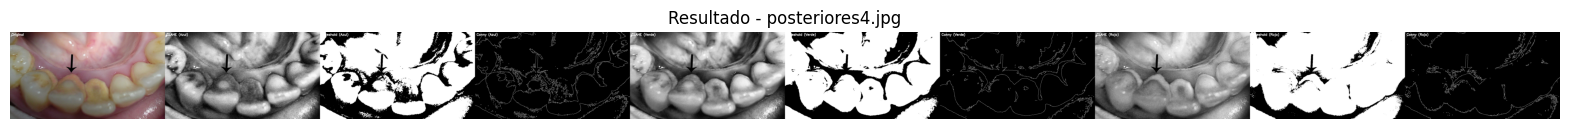

In [6]:
    # ==========================================
    # 5. MENSAJE FINAL
    # ==========================================
    if archivos_encontrados == 0:
        print(f"⚠️ No se encontraron imágenes dentro de la carpeta '{nombre_carpeta}'.")
    else:
        print("\n🎉 Procesamiento completado.")
        print(f"Las imágenes procesadas están en: {carpeta_salida}")
# ciclo para saber si el contador sigue en 0 o si encontro imagenes, las proceso y dónde las guardo
# Mostrar imagen resultante en notebook
plt.figure(figsize=(20, 6))
plt.imshow(cv2.cvtColor(imagen_combinada, cv2.COLOR_BGR2RGB))
plt.title(f"Resultado - {archivo_imagen}")
plt.axis("off")
plt.show()